In [63]:
import pandas as pd
import numpy as np
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge
import statsmodels.api as sm
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
folder = "/Users/alinahusainova/data/"
pd.set_option ('display.max_columns', None)

In [11]:
var_values = pd.read_csv(folder+"bd_VNDN_Var_Values.csv",
              encoding="UTF-8",
              sep=";")

ctg = list(var_values['variable'].drop_duplicates())

ctg_vars = {}
for v in ctg:
    ctg_vars[v] = 'category'
print(len(ctg_vars))

199


In [12]:
data = pd.read_csv(folder+"IND_OSN_VNDN_all.csv",
                   dtype=ctg_vars,
                   encoding="UTF-8")

In [13]:
df = data[data['source']>2016].copy()
print(data.shape, df.shape)

del data

(1719491, 268) (1370377, 268)


In [14]:
df.describe()

,H00_06,H01_00,H01_02,H01_05,H01_06,H01_12,H01_14,H02_02,H02_05,H02_06,H02_07,I01_02,I01_05,I01_06,I01_07,I02_17_01,R_10_1_3,R_10_1_4,R_10_1_5,R_10_1_6,R_10_1_7,R_DEN,R_FOT_NALOG,R_I03_16_17,R_I03_19,R_I_SAM,R_I_SAM_NALOG,R_I_DOP,R_I_DOP_NALOG,R_I_DR,R_I_DR_NALOG,R_I_UVOL_SUM,R_I_PENS,R_I_VZR_DETI_POSOB,R_I02_11_NCU_F_SUM,R_I_H02_30_NCU_DETI_INV,R_I_DET_POS_KOM_LG,H02_12_02,R_I_EGM_DITI_18,R_H02_13_03,R_H02_14_03,R_H02_18_20_SUM,R_H02_09_11_SUM,H02_33,R_H02_16_SUM,R_I_STIP,R_I_PIT_TR_DEN_LG,R_I_PIT_TR_LG,R_H02_28_06_NAT_DEN,R_I01_25_04_NAT_DEN,R_I02_18,R_I_POTER_RAB,MALOIM,KVZV,source,PM_DET,PM_TRUD,PM_PENS,I03_42_04_03,R_I03_42_03_03,R_I_H_I02_15,R_I_DOX_DEN,KMNS,R_I_NALOG,PM_TRUD_6,PM_PENS_6,R_H02_13_14_03,R_H02_36,R_I02_15_02_03
count,1.370377e+06,1.370377e+06,1.370377e+06,647875.000000,647875.000000,306868.000000,1.370377e+06,278469.000000,278469.000000,278469.000000,3882.000000,1.091908e+06,0.0,0.0,0.0,77091.000000,0.0,10974.0,14278.0,55705.0,33087.0,1.370377e+06,4.829690e+05,1.370377e+06,1.370377e+06,1.370377e+06,1.370377e+06,1.370377e+06,482969.000000,1.370377e+06,482969.000000,0.0,1.370377e+06,1.370377e+06,1.370377e+06,1.370377e+06,1.370377e+06,12902.000000,1.370377e+06,15130.000000,5915.000000,1.370377e+06,1.370377e+06,15055.000000,1.370377e+06,1.370377e+06,1.370377e+06,1.370377e+06,443.000000,41.000000,1.370377e+06,1.370377e+06,842238.000000,1.370377e+06,1.370377e+06,278469.000000,434980.000000,237733.000000,1.081000e+03,522.000000,1.370377e+06,1.370377e+06,37548.0,8.650520e+05,306000.000000,151319.000000,597459.000000,597459.000000,5.974590e+05
mean,5.756543e+04,1.985052e+00,4.053685e+01,1996.496426,2.052455,1.321076,1.153422e+00,8.066370,3.883639,26.577863,1.183668,4.879705e+01,NaN,NaN,NaN,2013.978441,NaN,1.0,1.0,1.0,1.0,1.732652e+05,5.724715e+04,5.785972e+02,9.016860e+01,9.018306e+03,7.599713e+02,1.485662e+03,461.832797,3.411891e+02,83.280396,NaN,6.093445e+04,6.610842e+03,4.276728e+02,2.720920e+01,5.646104e+03,20900.004108,2.167068e+03,56669.550760,14008.122232,2.061900e+02,3.433900e+02,6326.730521,4.835182e+01,3.200851e+02,8.692098e+02,8.383833e+02,11998.975169,46345.170732,3.263361e+03,2.191562e+02,0.183702,6.399781e+02,2.019945e+03,11965.120321,11712.889903,8333.827053,4.665617e+04,67684.371648,2.390118e+02,1.738438e+05,1.0,2.301726e+04,14371.006304,10404.578575,2351.907388,2052.696309,2.180994e+03
std,4.375110e+04,1.146885e+00,2.277828e+01,15.467666,6.790840,0.631714,4.249051e-01,4.413678,15.134949,42.487886,0.470748,1.757582e+01,NaN,NaN,NaN,3.847708,NaN,0.0,0.0,0.0,0.0,2.816995e+05,3.973153e+04,7.626509e+03,2.507590e+03,8.569296e+04,1.091395e+04,2.075934e+04,4246.401547,1.030452e+04,1766.006062,NaN,9.578306e+04,2.750304e+04,2.368159e+03,5.964331e+02,2.485393e+04,10042.848333,1.591349e+04,44780.926655,30900.414312,1.644893e+03,5.730521e+03,9847.752653,1.068715e+03,4.446544e+03,4.814442e+03,4.653321e+03,12680.165936,78240.843749,3.962563e+04,3.211764e+03,0.387241,1.155300e+03,2.413527e+00,2979.874840,2913.054187,1480.784151,1.083431e+05,73633.367606,4.423088e+03,2.831859e+05,0.0,3.991384e+04,3556.351676,1953.345993,18683.694183,5766.248880,1.629703e+04
min,1.000000e+00,1.000000e+00,0.000000e+00,1944.000000,1.000000,1.000000,1.000000e+00,0.000000,1.000000,1.000000,1.000000,1.600000e+01,NaN,NaN,NaN,2007.000000,NaN,1.0,1.0,1.0,1.0,0.000000e+00,1.643678e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,15503.000000,0.000000e+00,2908.000000,50.000000,0.000000e+00,0.000000e+00,100.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,477.000000,800.000000,0.000000e+00,0.000000e+00,0.000000,1.000000e+00,2.017000e+03,7568.500000,8459.250000,6489.250000,5.000000e+02,1000.000000,0.000000e+00,0.000000e+00,1.0,0.000000e+00,9927.750000,7670.000000,0.000000,0.000000,0.000000e+00
25%,2.324100e+04,1.000000e+00,2.100000e+01,1984.000000,1.000000,1.000000,1.000000e+00,4.000000,1.000000,1.000000,1.000000,3.50

In [15]:
df

,H00_02,H00_04,H00_06,I00_08,H01_00,H01_01,H01_02,H01_03,H01_04,H01_05,H01_06,H01_07,H01_08,H01_09,H01_10,H01_11,H01_12,H01_13,H01_14,H02_02,H02_05,H02_06,H02_07,H02_08_01,H02_08_02,H02_08_03,H02_08_04,H02_08_05,H02_08_06,H02_08_07,H02_10_01,H02_11_01,H02_11_04,H02_12_01,H02_13_01,H02_14_01,H02_15_01,H02_15_02,H02_15_03,H02_17,H02_18_01,H02_19,H02_21_01,H02_21_02,H02_21_03,H02_21_04,H02_22_01,H02_23,H02_24,H02_28_01,H02_28_02,H02_28_03,H02_28_04,H02_28_05,H02_28_09,H02_29_01,H02_29_02,H02_29_03,H02_29_04,H02_30_01,H02_30_05,H02_30_09,H02_30_13,H02_30_16,H02_30_17,H02_30_18,H02_30_19,H02_30_20,H02_31_01,H02_32_01,H02_32_02,H02_32_03,H02_32_04,H02_32_05,H02_32_06,H02_32_07,H02_32_08,H02_34,I01_02,I01_05,I01_06,I01_07,I01_08_01,I01_10,I01_11,I01_12_01,I01_12_02,I01_12_03,I01_14,I01_15,I01_16,I01_17,I01_21,I01_22,I01_23,I01_25_01,I01_25_02,I01_25_03,I01_25_06,I01_26_01,I02_01,I02_02_01,I02_02_02,I02_03,I02_09_01_01,I02_09_01_02,I02_09_01_03,I02_09_02_01,I02_09_02_02,I02_09_02_03,I02_09_02_04,I02_10,I02_11_01,I02_11_02,I02_11_03,I02_11_04,I02_12_01,I02_12_02,I02_12_03,I02_12_04,I02_12_05,I02_12_06,I02_12_07,I02_13,I02_15_01,I02_15_05,I02_16,I02_17_01,I02_18_01_01,I02_18_02_01,I02_19,MONOPROF,ARK,FED_OKR,R_1_1,R_1_1_1,POL,R_2_0,CH_0_17,MOL_SEM,MNG_SEM,NP_SEM,R_3_1,CH_0_15,CH_TRUD,CH_ST_TRUD,GL_DH,GL_DH_VOZR,STUD_18_24,R_5_1,R_5_2,R_8_1,R_8_2,R_9_1_1,R_9_2_1,MAM_15,PAP_15,MAM_3,PAP_3,R_5_3_1,R_5_3_3,R_7_1,R_7_1_1,R_7_1_2,R_7_1_3,R_7_1_4,R_7_1_5,R_10_1,R_10_1_3,R_10_1_4,R_10_1_5,R_10_1_6,R_10_1_7,R_7_2,R_7_2_1,R_7_2_2,R_7_2_3,R_7_2_4,R_7_2_5,R_10_2,R_10_3_1,R_10_3_3,VZR_RAB,VZR_NRAB,PENS,INV,R_DEN,R_FOT_NALOG,R_I03_16_17,R_I03_19,R_I_SAM,R_I_SAM_NALOG,R_I_DOP,R_I_DOP_NALOG,R_I_DR,R_I_DR_NALOG,R_I_UVOL_SUM,I03_44,R_I_PENS,R_I_VZR_DETI_POSOB,R_I02_11_NCU_F_SUM,R_I_H02_30_NCU_DETI_INV,R_I_DET_POS_KOM_LG,H02_12_02,R_I_EGM_DITI_18,R_H02_13_03,R_H02_14_03,R_H02_18_20_SUM,R_H02_09_11_SUM,H02_33,R_H02_16_SUM,R_I_STIP,R_I_PIT_TR_DEN_LG,R_I_PIT_TR_LG,R_H02_28_06_NAT_DEN,R_I01_25_04_NAT_DEN,R_I02_18,R_I_POTER_RAB,MALOIM,KVZV,source,H00_07,I01_24_01_01,I01_24_02_01,I01_24_03_01,I01_24_04_01,CHLICN,PM_DET,PM_TRUD,PM_PENS,CH_0_2,CH_0_8,I03_42_04_03,R_I03_42_03_03,R_I_H_I02_15,R_I_DOX_DEN,I01_30_01_01,I01_30_01_02,I01_30_02_01,I01_30_02_02,I01_30_03_01,I01_30_03_02,I01_30_04_01,I01_30_04_02,KMNS,R_I_NALOG,H02_121,I00_17,H02_31_04,H02_31_09,I02_17_1,I02_17_02_01,I02_18_01,CH_TRUD_6,CH_ST_TRUD_6,MALOIM_6,PM_TRUD_6,PM_PENS_6,R_H02_13_14_03,R_H02_36,R_I02_15_02_03,H02_11_07,I02_15_1,I02_15_2_01,H02_31_13,I02_15_5,I02_15_03_01,H02_31_1_01
349114,54,городской,92420.0,NaN,1.0,женский,53.0,ответственное лицо,разведен (а),NaN,NaN,проживает постоянно,Да,NaN,Да,NaN,NaN,одиночка,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,53.0,NaN,NaN,NaN,NaN,"высшее - специалитет, магистратура",NaN,NaN,NaN,NaN,Нет,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Нет,NaN,NaN,NaN,NaN,NaN,не относится ни к одной из перечисленных катег...,NaN,NaN,NaN,не относится ни к одной из перечисленных катег...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,центральный федеральный округ,городской,"менее 50,0",NaN,1 респондент,NaN,NaN,NaN,NaN,50 - 54,NaN,трудоспособный возраст,NaN,Глава ДХ,NaN,NaN,высшее профессиональное (высшее),NaN,специалисты высшего уровня квалификации,NaN,государственное управление и обеспечение военн...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,занятые в формальном секторе на основной работе,"по найму на предприятиях, в организациях",NaN,NaN,занятый в экономике (работающий),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,работающие взрослые,NaN,NaN,NaN,206896.551724,26896.551724,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,NaN,0.0,0.0,NaN,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0,45.000620,2017,"менее 50,0",NaN,NaN,NaN,N

In [16]:
cols = ['H00_06','H01_01','H00_02','H01_13','H01_02','CH_0_17','R_10_1','R_7_1_2','R_8_1',
        'KVZV','R_9_1_1','R_DEN','R_I_DOX_DEN','R_FOT_NALOG','R_I_SAM','R_I_DOP',
        'R_I_DR','R_I_PENS','source','H00_04','I01_10','MOL_SEM','MNG_SEM','NP_SEM',
        'I02_01','R_7_1_1','R_3_1','R_7_1_3','H00_07','H01_03','H01_04','H01_07','R_2_0']

t = (df['R_I_DOX_DEN'] > 0) & (df['R_I_DOX_DEN'].isna() == False)
print(sum(t))
t = (df['R_DEN'] > 0) & (df['R_DEN'].isna() == False) | t
print(sum(t))
t = (df['R_I_SAM'] > 0) & (df['R_I_SAM'].isna() == False) | t
print(sum(t))
t = (df['R_I_DOP'] > 0) & (df['R_I_DOP'].isna() == False) | t
print(sum(t))
t = (df['R_I_DR'] > 0) & (df['R_I_DR'].isna() == False) | t
print(sum(t))
t = (df['R_I_PENS'] > 0) & (df['R_I_PENS'].isna() == False) | t
print(sum(t))

df = df.loc[t][cols]
df.head(3)

571336
571336
598637
598637
598776
970596


,H00_06,H01_01,H00_02,H01_13,H01_02,CH_0_17,R_10_1,R_7_1_2,R_8_1,KVZV,R_9_1_1,R_DEN,R_I_DOX_DEN,R_FOT_NALOG,R_I_SAM,R_I_DOP,R_I_DR,R_I_PENS,source,H00_04,I01_10,MOL_SEM,MNG_SEM,NP_SEM,I02_01,R_7_1_1,R_3_1,R_7_1_3,H00_07,H01_03,H01_04,H01_07,R_2_0
349114,92420.0,женский,54,одиночка,53.0,NaN,занятый в экономике (работающий),занятые в формальном секторе на основной работе,специалисты высшего уровня квалификации,45.000620,государственное управление и обеспечение военн...,206896.551724,206896.551724,26896.551724,0.0,0.0,0.0,0.0,2017,городской,"высшее - специалитет, магистратура",NaN,NaN,NaN,Нет,NaN,50 - 54,"по найму на предприятиях, в организациях","менее 50,0",ответственное лицо,разведен (а),проживает постоянно,1 респондент
349115,43371.0,женский,29,одиночка,69.0,NaN,не занятый в экономике (не работающий),NaN,NaN,231.543775,NaN,0.000000,0.000000,NaN,0.0,0.0,0.0,171600.0,2017,городской,среднее профессиональное по программе подготов...,NaN,NaN,NaN,Да,NaN,65 - 69,NaN,"250,0- 499,9",ответственное лицо,вдовец/вдова,проживает постоянно,1 респондент
349116,154535.0,мужской,94,супружеская пара с детьми до 18 лет,29.0,NaN,занятый в экономике (работающий),занятые в формальном секторе на основной работе,квалифицированные работники сельского и лесног...,358.764108,"сельское хозяйство, охота и лесное хозяйство, ...",138505.747126,139505.747126,18005.747126,0.0,0.0,0.0,0.0,2017,сельский,среднее общее (среднее полное общее),NaN,NaN,NaN,Нет,NaN,25 - 29,"по найму на предприятиях, в организациях",201 - 1000,зять/невестка,состоит в незарегистрированном браке,проживает постоянно,5 и более респондентов


In [17]:
df['R_10_1'].dtype

CategoricalDtype(categories=['занятый в экономике (работающий)', 'не занятый в экономике (не работающий)'], ordered=False, categories_dtype=object)

In [18]:
df = df[df['R_10_1']=='занятый в экономике (работающий)']
print(df.shape)

(598923, 33)


In [19]:
df.dtypes

H00_06          float64
H01_01         category
H00_02         category
H01_13         category
H01_02          float64
CH_0_17        category
R_10_1         category
R_7_1_2        category
R_8_1          category
KVZV            float64
R_9_1_1        category
R_DEN           float64
R_I_DOX_DEN     float64
R_FOT_NALOG     float64
R_I_SAM         float64
R_I_DOP         float64
R_I_DR          float64
R_I_PENS        float64
source            int64
H00_04         category
I01_10         category
MOL_SEM        category
MNG_SEM        category
NP_SEM         category
I02_01         category
R_7_1_1        category
R_3_1          category
R_7_1_3        category
H00_07         category
H01_03         category
H01_04         category
H01_07         category
R_2_0          category
dtype: object

In [20]:
df['H00_02'] = df['H00_02'].astype(int)

In [21]:
for v in df.columns[df.dtypes=='category']:
    print(v, set(df[v]))

H01_01 {'женский', 'мужской'}
H01_13 {'ребенок до 18 лет, проживающий без родителей', 'ребенок до 18 лет, не имеющий родителей', 'одиночка', 'супружеская пара', 'одиночка с детьми до 18 лет', 'супружеская пара с детьми до 18 лет'}
CH_0_17 {nan, '0.0', 'ребенок до 18 лет'}
R_10_1 {'занятый в экономике (работающий)'}
R_7_1_2 {nan, 'занятые в формальном секторе на основной работе', 'занятые в неформальном секторе на основной работе'}
R_8_1 {'работники сферы обслуживания и торговли, охраны граждан и со', nan, 'операторы производственных установок и машин, сборщики и вод', 'специалисты высшего уровня квалификации', 'квалифицированные работники сельского и лесного хозяйства, р', 'неквалифицированные рабочие', 'служащие, занятые подготовкой и оформлением документации, уч', 'руководители', 'специалисты среднего уровня квалификации'}
R_9_1_1 {nan, 'сельское хозяйство, охота и лесное хозяйство, рыболовство, р', 'прочая деятельность', 'торговля, ремонт автотранспортных средств, гостиницы и предп'

In [22]:
df['sum_dox'] = df['R_DEN']*df['KVZV']

avg_dox = df.groupby(['source']).agg(Sum=('sum_dox','sum'),Nas=('KVZV','sum'))
avg_dox['avg_r_den']=avg_dox['Sum']/avg_dox['Nas']
avg_dox = avg_dox[['avg_r_den']]

df = df.join(avg_dox, on='source')
df['r_den_otn'] = df['R_DEN']/df['avg_r_den']

In [23]:
var = 'R_9_1_1'
s = list(set(df[var].astype(str)))
s.sort()
print(len(s),'\n','\n'.join(s))

df[var] = df[var].astype(str).str.lower().str.strip().str.replace('  ',' ').str[:52].astype('category')
s = list(set(df[var]))
s.sort()
print(len(s),'\n','\n'.join(s))

13 
 nan
государственное управление и обеспечение военной безопасност
деятельность в области культуры, спорта, организации досуга
деятельность финансовая и страховая, по операциям с недвижи
деятельность финансовая и страховая, по операциям с недвижим
добыча полезных ископаемых, обрабатывающая промышленность, о
здравоохранение и предоставление социальных услуг
образование
прочая деятельность
сельское хозяйство, охота и лесное хозяйство, рыболовство,
сельское хозяйство, охота и лесное хозяйство, рыболовство, р
строительство
торговля, ремонт автотранспортных средств, гостиницы и предп
11 
 nan
государственное управление и обеспечение военной без
деятельность в области культуры, спорта, организации
деятельность финансовая и страховая, по операциям с 
добыча полезных ископаемых, обрабатывающая промышлен
здравоохранение и предоставление социальных услуг
образование
прочая деятельность
сельское хозяйство, охота и лесное хозяйство, рыболо
строительство
торговля, ремонт автотранспортных средств

In [24]:
var = 'R_8_1'
s = list(set(df[var].astype(str)))
s.sort()
print(len(s),'\n','\n'.join(s))


df[var] = df[var].astype(str).str.lower().str.strip().str.replace('  ',' ').str[:52].astype('category')
s = list(set(df[var]))
s.sort()
print(len(s),'\n','\n'.join(s))

9 
 nan
квалифицированные работники сельского и лесного хозяйства, р
неквалифицированные рабочие
операторы производственных установок и машин, сборщики и вод
работники сферы обслуживания и торговли, охраны граждан и со
руководители
служащие, занятые подготовкой и оформлением документации, уч
специалисты высшего уровня квалификации
специалисты среднего уровня квалификации
9 
 nan
квалифицированные работники сельского и лесного хозя
неквалифицированные рабочие
операторы производственных установок и машин, сборщи
работники сферы обслуживания и торговли, охраны граж
руководители
служащие, занятые подготовкой и оформлением документ
специалисты высшего уровня квалификации
специалисты среднего уровня квалификации


In [25]:
var = 'I01_10'
s = list(set(df[var].astype(str)))
s.sort()
print(len(s),'\n','\n'.join(s))

16 
 высшее - бакалавриат
высшее - специалитет, магистратура
кадры высшей квалификации (послевузовское)
кадры высшей квалификации (послевузовское) - аспирантура, до
не имеете основного общего
не имеется основного общего
неполное высшее (незаконченное высшее)
неполное высшее (незаконченное высшее) - оконченные 3 курса
основное общее
основное общее (неполное среднее)
среднее общее
среднее общее (среднее полное общее)
среднее профессиональное - по программам подготовки квалифиц
среднее профессиональное по программе подготовки квалифициро
среднее профессиональное по программе подготовки специалисто
среднее профессиональное-по программам подготовки специалист


In [26]:
replaces = {"имеется":"имеете",
            " - аспирантура, до":"",
            " - оконченные 3 курса":"",
            " (среднее полное общее)":"",
            " (неполное среднее)":"",
            " - по программам подготовки квалифиц":" по программе подготовки квалифициро",
            "-по программам подготовки специалист":" по программе подготовки специалисто"
           }
replaces.keys()

dict_keys(['имеется', ' - аспирантура, до', ' - оконченные 3 курса', ' (среднее полное общее)', ' (неполное среднее)', ' - по программам подготовки квалифиц', '-по программам подготовки специалист'])

In [27]:
for k in replaces.keys():
    df['I01_10'] = df['I01_10'].str.replace(k,replaces[k]).astype('category')

In [28]:
var = 'I01_10'
s = list(set(df[var].astype(str)))
s.sort()
print(len(s),'\n','\n'.join(s))

9 
 высшее - бакалавриат
высшее - специалитет, магистратура
кадры высшей квалификации (послевузовское)
не имеете основного общего
неполное высшее (незаконченное высшее)
основное общее
среднее общее
среднее профессиональное по программе подготовки квалифициро
среднее профессиональное по программе подготовки специалисто


In [29]:
var = 'H01_04'
s = list(set(df[var].astype(str)))
s.sort()
print(len(s),'\n','\n'.join(s))

11 
 вдовец/вдова
никогда не состоял(а) в браке
никогда не состоял(а) в браке, супружеском союзе
разведен (а)
разведен (а) официально
разведен(а) официально
разошелся (лась)
разошелся(ась)
состоит в зарегистрированном браке
состоит в незарегистрированном браке
состоит в незарегистрированном супружеском союзе


In [30]:
replaces = {", супружеском союзе":"",
            " официально":"",
            " (лась)":"(ась)",
            " (":"(",
            "незарегистрированном супружеском союзе":"незарегистрированном браке"
           }
replaces.keys()

dict_keys([', супружеском союзе', ' официально', ' (лась)', ' (', 'незарегистрированном супружеском союзе'])

In [31]:
var = 'H01_04'
for k in replaces.keys():
    df[var] = df[var].str.replace(k,replaces[k])
df[var] = df[var].astype('category')

s = list(set(df[var].astype(str)))
s.sort()
print(len(s),'\n','\n'.join(s))

6 
 вдовец/вдова
никогда не состоял(а) в браке
разведен(а)
разошелся(ась)
состоит в зарегистрированном браке
состоит в незарегистрированном браке


In [32]:
df

,H00_06,H01_01,H00_02,H01_13,H01_02,CH_0_17,R_10_1,R_7_1_2,R_8_1,KVZV,R_9_1_1,R_DEN,R_I_DOX_DEN,R_FOT_NALOG,R_I_SAM,R_I_DOP,R_I_DR,R_I_PENS,source,H00_04,I01_10,MOL_SEM,MNG_SEM,NP_SEM,I02_01,R_7_1_1,R_3_1,R_7_1_3,H00_07,H01_03,H01_04,H01_07,R_2_0,sum_dox,avg_r_den,r_den_otn
349114,92420.0,женский,54,одиночка,53.0,NaN,занятый в экономике (работающий),занятые в формальном секторе на основной работе,специалисты высшего уровня квалификации,45.000620,государственное управление и обеспечение военн...,2.068966e+05,2.068966e+05,26896.551724,0.0,0.0,0.0,0.0,2017,городской,"высшее - специалитет, магистратура",NaN,NaN,NaN,Нет,NaN,50 - 54,"по найму на предприятиях, в организациях","менее 50,0",ответственное лицо,разведен(а),проживает постоянно,1 респондент,9.310473e+06,410791.469044,0.503653
349116,154535.0,мужской,94,супружеская пара с детьми до 18 лет,29.0,NaN,занятый в экономике (работающий),занятые в формальном секторе на основной работе,квалифицированные работники сельского и лесног...,358.764108,"сельское хозяйство, охота и лесное хозяйство, ...",1.385057e+05,1.395057e+05,18005.747126,0.0,0.0,0.0,0.0,2017,сельский,среднее общее,NaN,NaN,NaN,Нет,NaN,25 - 29,"по найму на предприятиях, в организациях",201 - 1000,зять/невестка,состоит в незарегистрированном браке,проживает постоянно,5 и более респондентов,4.969089e+07,410791.469044,0.337168
349119,154535.0,женский,94,супружеская пара с детьми до 18 лет,26.0,NaN,занятый в экономике (работающий),занятые в формальном секторе на основной работе,"работники сферы обслуживания и торговли, охран...",358.764108,"торговля, ремонт автотранспортных средств, гос...",2.068966e+05,2.068966e+05,26896.551724,0.0,0.0,0.0,0.0,2017,сельский,неполное высшее (незаконченное высшее),NaN,NaN,NaN,Нет,NaN,25 - 29,"по найму на предприятиях, в организациях",201 - 1000,сын/дочь,состоит в незарегистрированном браке,проживает постоянно,5 и более респондентов,7.422706e+07,410791.469044,0.503653
349123,60533.0,мужской,40,одиночка,30.0,NaN,занятый в экономике (работающий),занятые в формальном секторе на основной работе,специалисты высшего уровня квалификации,430.716591,"деятельность в области культуры, спорта, орган...",6.505747e+05,6.505747e+05,84574.712643,0.0,0.0,0.0,0.0,2017,городской,"высшее - специалитет, магистратура",NaN,NaN,NaN,Нет,NaN,30 - 34,"по найму на предприятиях, в организациях",1 млн. и более,ответственное лицо,никогда не состоял(а) в браке,проживает постоянно,1 респондент,2.802133e+08,410791.469044,1.583710
349124,102383.0,женский,60,одиночка,50.0,NaN,занятый в экономике (работающий),занятые в формальном секторе на основной работе,"работники сферы обслуживания и торговли, охран...",116.584197,образование,1.230345e+05,1.230345e+05,15994.482758,0.0,0.0,0.0,0.0,2017,сельский,среднее профессиональное по программе подготов...,NaN,NaN,NaN,Нет,NaN,50 - 54,"по найму на предприятиях, в организациях",более 5000,ответственное лицо,разведен(а),проживает постоянно,2 респондента,1.434388e+07,410791.469044,0.299506
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1697821,59999.0,мужской,719,супружеская пара с детьми до 18 лет,43.0,0.0,занятый в экономике (работающий),занятые в формальном секторе на основной работе,специалисты среднего уровня квалификации,1855.736527,прочая деятельность,1.005747e+06,1.005747e+06,130747.126436,0.0,0.0,0.0,0.0,2024,сельский,"высшее - специалитет, магистратура",NaN,Многодетная семья,NaN,Нет,NaN,40 - 44,"по найму на предприятиях, в организациях",сельский более 5000,жена/муж,состоит в зарегистрированном браке,постоянно проживает,5 и более лиц,1.866402e+09,702777.384499,1.431103
1697822,59999.0,женский,719,супружеская пара с детьми до 18 лет,38.0,0.0,занятый в экономике (работающий),занятые в формальном секторе на основной работе,специалисты высшего уровня квалификации,1855.736527,"деятельность финансовая и страховая, по операц...",1.333000e+06,1.333000e+06,169000.000000,0.0,0.0,0.0,0.0,2024,сел

In [36]:
reg_okved_okz = pd.read_excel("данные для добавления.xlsx",sheet_name="OtnDox_Reg_OKVED_OKZ")
reg_okved_okz.head()

,H00_02,R_8_1,R_9_1_1,source,Относительный доход отрасли,Относительный доход региона,Относительный доход занятия,ОтнДОх_Рег_Отр
0,54,специалисты высшего уровня квалификации,государственное управление и обеспечение военн...,2017,1.17114,0.63143,1.16705,0.92135
1,94,квалифицированные работники сельского и лесног...,"сельское хозяйство, охота и лесное хозяйство, ...",2017,0.66293,0.75800,0.88421,0.52385
2,94,"работники сферы обслуживания и торговли, охран...","торговля, ремонт автотранспортных средств, гос...",2017,1.05741,0.75800,0.67652,0.72070
3,40,специалисты высшего уровня квалификации,"деятельность в области культуры, спорта, орган...",2017,0.79050,1.37050,1.16705,1.19419
4,60,"работники сферы обслуживания и торговли, охран...",образование,2017,0.78138,0.72014,0.67652,0.57452


In [37]:
reg_okved_okz.dtypes

H00_02                           int64
R_8_1                           object
R_9_1_1                         object
source                           int64
Относительный доход отрасли    float64
Относительный доход региона    float64
Относительный доход занятия    float64
ОтнДОх_Рег_Отр                 float64
dtype: object

In [38]:
t = df
t['H00_02'] = t['H00_02'].astype(int)
t = t.set_index(['H00_02','R_8_1','R_9_1_1','source']).\
        join(reg_okved_okz.set_index(['H00_02','R_8_1','R_9_1_1','source']),
             on=['H00_02','R_8_1','R_9_1_1','source'], 
             how = 'left').reset_index()
t['H00_02'] = t['H00_02'].astype(str).astype('category')
print(t.shape)

(598923, 40)


In [39]:
t.head()

,H00_02,R_8_1,R_9_1_1,source,H00_06,H01_01,H01_13,H01_02,CH_0_17,R_10_1,R_7_1_2,KVZV,R_DEN,R_I_DOX_DEN,R_FOT_NALOG,R_I_SAM,R_I_DOP,R_I_DR,R_I_PENS,H00_04,I01_10,MOL_SEM,MNG_SEM,NP_SEM,I02_01,R_7_1_1,R_3_1,R_7_1_3,H00_07,H01_03,H01_04,H01_07,R_2_0,sum_dox,avg_r_den,r_den_otn,Относительный доход отрасли,Относительный доход региона,Относительный доход занятия,ОтнДОх_Рег_Отр
0,54,специалисты высшего уровня квалификации,государственное управление и обеспечение военн...,2017,92420.0,женский,одиночка,53.0,NaN,занятый в экономике (работающий),занятые в формальном секторе на основной работе,45.000620,206896.551724,206896.551724,26896.551724,0.0,0.0,0.0,0.0,городской,"высшее - специалитет, магистратура",NaN,NaN,NaN,Нет,NaN,50 - 54,"по найму на предприятиях, в организациях","менее 50,0",ответственное лицо,разведен(а),проживает постоянно,1 респондент,9.310473e+06,410791.469044,0.503653,1.17114,0.63143,1.16705,0.92135
1,94,квалифицированные работники сельского и лесног...,"сельское хозяйство, охота и лесное хозяйство, ...",2017,154535.0,мужской,супружеская пара с детьми до 18 лет,29.0,NaN,занятый в экономике (работающий),занятые в формальном секторе на основной работе,358.764108,138505.747126,139505.747126,18005.747126,0.0,0.0,0.0,0.0,сельский,среднее общее,NaN,NaN,NaN,Нет,NaN,25 - 29,"по найму на предприятиях, в организациях",201 - 1000,зять/невестка,состоит в незарегистрированном браке,проживает постоянно,5 и более респондентов,4.969089e+07,410791.469044,0.337168,0.66293,0.75800,0.88421,0.52385
2,94,"работники сферы обслуживания и торговли, охран...","торговля, ремонт автотранспортных средств, гос...",2017,154535.0,женский,супружеская пара с детьми до 18 лет,26.0,NaN,занятый в экономике (работающий),занятые в формальном секторе на основной работе,358.764108,206896.551724,206896.551724,26896.551724,0.0,0.0,0.0,0.0,сельский,неполное высшее (незаконченное высшее),NaN,NaN,NaN,Нет,NaN,25 - 29,"по найму на предприятиях, в организациях",201 - 1000,сын/дочь,состоит в незарегистрированном браке,проживает постоянно,5 и более респондентов,7.422706e+07,410791.469044,0.503653,1.05741,0.75800,0.67652,0.72070
3,40,специалисты высшего уровня квалификации,"деятельность в области культуры, спорта, орган...",2017,60533.0,мужской,одиночка,30.0,NaN,занятый в экономике (работающий),занятые в формальном секторе на основной работе,430.716591,650574.712643,650574.712643,84574.712643,0.0,0.0,0.0,0.0,городской,"высшее - специалитет, магистратура",NaN,NaN,NaN,Нет,NaN,30 - 34,"по найму на предприятиях, в организациях",1 млн. и более,ответственное лицо,никогда не состоял(а) в браке,проживает постоянно,1 респондент,2.802133e+08,410791.469044,1.583710,0.79050,1.37050,1.16705,1.19419
4,60,"работники сферы обслуживания и торговли, охран...",образование,2017,102383.0,женский,одиночка,50.0,NaN,занятый в экономике (работающий),занятые в формальном секторе на основной работе,116.584197,123034.482758,123034.482758,15994.482758,0.0,0.0,0.0,0.0,сельский,среднее профессиональное по программе подготов...,NaN,NaN,NaN,Нет,NaN,50 - 54,"по найму на предприятиях, в организациях",более 5000,ответственное лицо,разведен(а),проживает постоянно,2 респондента,1.434388e+07,410791.469044,0.299506,0.78138,0.72014,0.67652,0.57452


In [40]:
t.count()

H00_02                         598923
R_8_1                          598923
R_9_1_1                        598923
source                         598923
H00_06                         598923
H01_01                         598923
H01_13                         598923
H01_02                         598923
CH_0_17                        316182
R_10_1                         598923
R_7_1_2                        598732
KVZV                           598923
R_DEN                          598923
R_I_DOX_DEN                    598923
R_FOT_NALOG                    482969
R_I_SAM                        598923
R_I_DOP                        598923
R_I_DR                         598923
R_I_PENS                       598923
H00_04                         598923
I01_10                         598923
MOL_SEM                         51376
MNG_SEM                         24973
NP_SEM                          45769
I02_01                         598923
R_7_1_1                         25786
R_3_1       

In [41]:
t1 = t['ОтнДОх_Рег_Отр'].isna()
sum(t1)

27587

In [42]:
t = t[t['ОтнДОх_Рег_Отр'].notna()]
t.head()

,H00_02,R_8_1,R_9_1_1,source,H00_06,H01_01,H01_13,H01_02,CH_0_17,R_10_1,R_7_1_2,KVZV,R_DEN,R_I_DOX_DEN,R_FOT_NALOG,R_I_SAM,R_I_DOP,R_I_DR,R_I_PENS,H00_04,I01_10,MOL_SEM,MNG_SEM,NP_SEM,I02_01,R_7_1_1,R_3_1,R_7_1_3,H00_07,H01_03,H01_04,H01_07,R_2_0,sum_dox,avg_r_den,r_den_otn,Относительный доход отрасли,Относительный доход региона,Относительный доход занятия,ОтнДОх_Рег_Отр
0,54,специалисты высшего уровня квалификации,государственное управление и обеспечение военн...,2017,92420.0,женский,одиночка,53.0,NaN,занятый в экономике (работающий),занятые в формальном секторе на основной работе,45.000620,206896.551724,206896.551724,26896.551724,0.0,0.0,0.0,0.0,городской,"высшее - специалитет, магистратура",NaN,NaN,NaN,Нет,NaN,50 - 54,"по найму на предприятиях, в организациях","менее 50,0",ответственное лицо,разведен(а),проживает постоянно,1 респондент,9.310473e+06,410791.469044,0.503653,1.17114,0.63143,1.16705,0.92135
1,94,квалифицированные работники сельского и лесног...,"сельское хозяйство, охота и лесное хозяйство, ...",2017,154535.0,мужской,супружеская пара с детьми до 18 лет,29.0,NaN,занятый в экономике (работающий),занятые в формальном секторе на основной работе,358.764108,138505.747126,139505.747126,18005.747126,0.0,0.0,0.0,0.0,сельский,среднее общее,NaN,NaN,NaN,Нет,NaN,25 - 29,"по найму на предприятиях, в организациях",201 - 1000,зять/невестка,состоит в незарегистрированном браке,проживает постоянно,5 и более респондентов,4.969089e+07,410791.469044,0.337168,0.66293,0.75800,0.88421,0.52385
2,94,"работники сферы обслуживания и торговли, охран...","торговля, ремонт автотранспортных средств, гос...",2017,154535.0,женский,супружеская пара с детьми до 18 лет,26.0,NaN,занятый в экономике (работающий),занятые в формальном секторе на основной работе,358.764108,206896.551724,206896.551724,26896.551724,0.0,0.0,0.0,0.0,сельский,неполное высшее (незаконченное высшее),NaN,NaN,NaN,Нет,NaN,25 - 29,"по найму на предприятиях, в организациях",201 - 1000,сын/дочь,состоит в незарегистрированном браке,проживает постоянно,5 и более респондентов,7.422706e+07,410791.469044,0.503653,1.05741,0.75800,0.67652,0.72070
3,40,специалисты высшего уровня квалификации,"деятельность в области культуры, спорта, орган...",2017,60533.0,мужской,одиночка,30.0,NaN,занятый в экономике (работающий),занятые в формальном секторе на основной работе,430.716591,650574.712643,650574.712643,84574.712643,0.0,0.0,0.0,0.0,городской,"высшее - специалитет, магистратура",NaN,NaN,NaN,Нет,NaN,30 - 34,"по найму на предприятиях, в организациях",1 млн. и более,ответственное лицо,никогда не состоял(а) в браке,проживает постоянно,1 респондент,2.802133e+08,410791.469044,1.583710,0.79050,1.37050,1.16705,1.19419
4,60,"работники сферы обслуживания и торговли, охран...",образование,2017,102383.0,женский,одиночка,50.0,NaN,занятый в экономике (работающий),занятые в формальном секторе на основной работе,116.584197,123034.482758,123034.482758,15994.482758,0.0,0.0,0.0,0.0,сельский,среднее профессиональное по программе подготов...,NaN,NaN,NaN,Нет,NaN,50 - 54,"по найму на предприятиях, в организациях",более 5000,ответственное лицо,разведен(а),проживает постоянно,2 респондента,1.434388e+07,410791.469044,0.299506,0.78138,0.72014,0.67652,0.57452


In [43]:
df = t
print(df.columns)

Index(['H00_02', 'R_8_1', 'R_9_1_1', 'source', 'H00_06', 'H01_01', 'H01_13',
       'H01_02', 'CH_0_17', 'R_10_1', 'R_7_1_2', 'KVZV', 'R_DEN',
       'R_I_DOX_DEN', 'R_FOT_NALOG', 'R_I_SAM', 'R_I_DOP', 'R_I_DR',
       'R_I_PENS', 'H00_04', 'I01_10', 'MOL_SEM', 'MNG_SEM', 'NP_SEM',
       'I02_01', 'R_7_1_1', 'R_3_1', 'R_7_1_3', 'H00_07', 'H01_03', 'H01_04',
       'H01_07', 'R_2_0', 'sum_dox', 'avg_r_den', 'r_den_otn',
       'Относительный доход отрасли', 'Относительный доход региона',
       'Относительный доход занятия', 'ОтнДОх_Рег_Отр'],
      dtype='object')


In [75]:
print(df['H01_02'].unique())
print(df['H01_02'].dtype)
print(df['H01_02'].head(7))
print(df['H01_02'].value_counts().head(15))

[53. 29. 26. 30. 50. 42. 38. 40. 52. 65. 44. 25. 54. 36. 58. 39. 60. 31.
 55. 34. 27. 51. 32. 46. 49. 64. 20. 35. 48. 61. 41. 73. 43. 21. 45. 57.
 22. 37. 63. 56. 59. 23. 24. 47. 33. 28. 66. 62. 69. 67. 70. 68. 19. 76.
 17. 74. 16. 18. 81. 71. 82. 72. 78. 75. 79. 85. 77. 80. 83. 87. 86. 84.
 88. 92. 95. 97.]
float64
0    53.0
1    29.0
2    26.0
3    30.0
4    50.0
5    42.0
6    38.0
Name: H01_02, dtype: float64
H01_02
40.0    19629
35.0    19222
38.0    18612
36.0    18463
37.0    17345
42.0    17282
39.0    17157
45.0    17061
34.0    16867
32.0    16525
30.0    16213
43.0    16139
41.0    15935
33.0    15798
44.0    15304
Name: count, dtype: int64


In [78]:
df['Пол_код'] = (df['H01_01'] == 'мужской').astype(int)
df['Возраст_число'] = df['H01_02']

print(df['Пол_код'].value_counts())

Пол_код
0    292948
1    278388
Name: count, dtype: int64


In [49]:
def weighted_mean_group(df, group_cols, weight_col='KVZV', target='r_den_otn'):
    result = df.groupby(group_cols).apply(
        lambda x: np.average(x[target], weights=x[weight_col]) if x[weight_col].sum() > 0 else x[target].mean()
    ).reset_index()
    result.columns = group_cols + [f'mean_{"_".join(group_cols)}']
    return result
groupings = {
    'region': ['H00_02'],
    'profession': ['R_8_1'],
    'industry': ['R_9_1_1'],
    'region_profession': ['H00_02', 'R_8_1'],
    'region_industry': ['H00_02', 'R_9_1_1'],
    'profession_industry': ['R_8_1', 'R_9_1_1'],
    'full': ['H00_02', 'R_8_1', 'R_9_1_1']
}
means = {}
for name, cols in groupings.items():
    means[name] = weighted_mean_group(df, cols)
    print(f"{name}: {len(means[name])} групп")

region: 88 групп
profession: 9 групп
industry: 11 групп
region_profession: 704 групп
region_industry: 879 групп
profession_industry: 80 групп
full: 6805 групп


In [50]:
def predict_with_hierarchy(df_new, means_dict, hierarchy, global_mean):
    df_result = df_new.copy()
    df_result['predicted'] = np.nan
    
    for group_name in hierarchy:
        if group_name not in means_dict:
            continue
            
        mean_df = means_dict[group_name]
        group_cols = groupings[group_name]
        mean_col = f'mean_{"_".join(group_cols)}'
        
        key = '__key__'
        df_result[key] = df_result[group_cols].astype(str).agg('_'.join, axis=1)
        mean_df[key] = mean_df[group_cols].astype(str).agg('_'.join, axis=1)
        
        df_result = df_result.merge(mean_df[[key, mean_col]], on=key, how='left')

        mask = df_result['predicted'].isna() & df_result[mean_col].notna()
        df_result.loc[mask, 'predicted'] = df_result.loc[mask, mean_col]
        
        df_result = df_result.drop(columns=[key, mean_col])
    
    df_result['predicted'] = df_result['predicted'].fillna(global_mean)
    return df_result

global_mean = np.average(df['r_den_otn'], weights=df['KVZV'])

hierarchy_priority = ['full', 'region_profession', 'region_industry', 
                      'profession_industry', 'region', 'profession', 'industry']

In [51]:
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42)
means_train = {}
for name, cols in groupings.items():
    means_train[name] = weighted_mean_group(df_train, cols)
df_test_pred = predict_with_hierarchy(df_test, means_train, hierarchy_priority, global_mean)

r2 = r2_score(df_test_pred['r_den_otn'], df_test_pred['predicted'])
mae = mean_absolute_error(df_test_pred['r_den_otn'], df_test_pred['predicted'])
print(f"R2: {r2:.4f}")
print(f"MAE: {mae:.4f}")


R2: 0.3574
MAE: 0.3329


In [79]:
df_agg = df.groupby(['H00_02', 'R_8_1', 'R_9_1_1']).agg(
    target_mean=('r_den_otn', 'mean'),
    weight=('KVZV', 'sum'),
    count=('r_den_otn', 'count'),
    gender_mean=('Пол_код', 'mean'),
    age_mean=('Возраст_число', 'mean') 
).reset_index()

df_agg = df_agg[df_agg['count'] >= 5]
print(f"Количество групп для линейной модели: {len(df_agg)}")

region_means = df.groupby('H00_02')['Относительный доход региона'].mean().to_dict()
industry_means = df.groupby('R_9_1_1')['Относительный доход отрасли'].mean().to_dict()
profession_means = df.groupby('R_8_1')['Относительный доход занятия'].mean().to_dict()

df_agg['region_mean'] = df_agg['H00_02'].map(region_means)
df_agg['industry_mean'] = df_agg['R_9_1_1'].map(industry_means)
df_agg['profession_mean'] = df_agg['R_8_1'].map(profession_means)

le_region = LabelEncoder()
le_prof = LabelEncoder()
le_ind = LabelEncoder()

df_agg['region_code'] = le_region.fit_transform(df_agg['H00_02'].astype(str))
df_agg['prof_code'] = le_prof.fit_transform(df_agg['R_8_1'].astype(str))
df_agg['ind_code'] = le_ind.fit_transform(df_agg['R_9_1_1'].astype(str))

feature_cols = ['region_mean', 'industry_mean', 'profession_mean', 'region_code', 'prof_code', 'ind_code', 'gender_mean', 'age_mean']
X = df_agg[feature_cols]
y = df_agg['target_mean']
X_const = sm.add_constant(X)

Количество групп для линейной модели: 6123


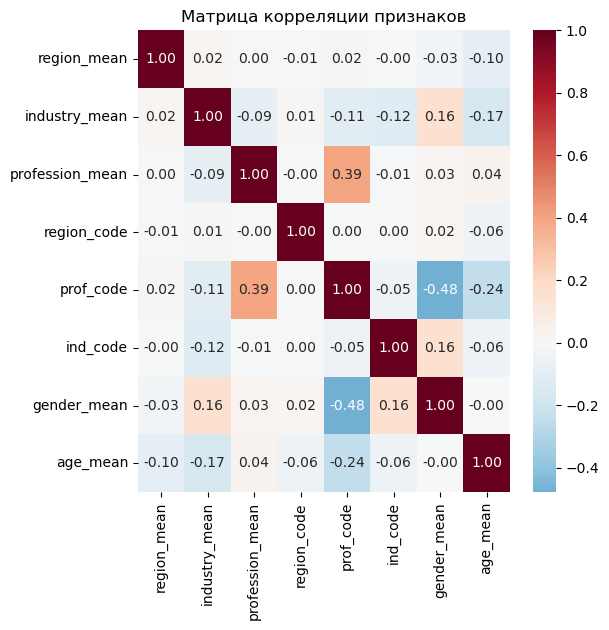

In [80]:
corr_matrix = X.corr()

plt.figure(figsize=(6, 6))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Матрица корреляции признаков')
plt.show()

In [81]:
model_ols = sm.OLS(y, X_const).fit()
print(model_ols.summary())

                            OLS Regression Results                            
Dep. Variable:            target_mean   R-squared:                       0.717
Model:                            OLS   Adj. R-squared:                  0.716
Method:                 Least Squares   F-statistic:                     1934.
Date:                Tue, 21 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:07:27   Log-Likelihood:                 934.63
No. Observations:                6123   AIC:                            -1851.
Df Residuals:                    6114   BIC:                            -1791.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.2466      0.039     

In [83]:
significant_features = ['region_mean', 'profession_mean', 'industry_mean', 'gender_mean', 'age_mean']

X_significant = df_agg[significant_features]
X_const = sm.add_constant(X_significant)

final_model = sm.OLS(y, X_const).fit()
print(final_model.summary())

                            OLS Regression Results                            
Dep. Variable:            target_mean   R-squared:                       0.711
Model:                            OLS   Adj. R-squared:                  0.711
Method:                 Least Squares   F-statistic:                     3015.
Date:                Tue, 21 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:09:35   Log-Likelihood:                 877.27
No. Observations:                6123   AIC:                            -1743.
Df Residuals:                    6117   BIC:                            -1702.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.3583      0.035     

In [43]:
feature_cols = [ 
    'H00_02',
    'H00_04',
    'H00_07',
    'H01_01', 
    'H01_13',
    'H01_02',
    'CH_0_17',
    'R_3_1',
    'R_7_1_1',
    'R_7_1_2',
    'R_7_1_3',
    'R_8_1',
    'R_9_1_1',
    'R_10_1',
    'I01_10',
    'I02_01',
    'MOL_SEM',
    'MNG_SEM',
    'NP_SEM',
    'H01_03',
    'H01_04',
    'H01_07',
    'R_2_0',
    'source',
    'Относительный доход отрасли',
    'Относительный доход региона',
    'Относительный доход занятия',
    'ОтнДОх_Рег_Отр'
]

target_col = 'r_den_otn'

In [45]:
df['H01_02'] = df['H01_02'].astype(int)

In [46]:
df[feature_cols]

,H00_02,H00_04,H00_07,H01_01,H01_13,H01_02,CH_0_17,R_3_1,R_7_1_1,R_7_1_2,R_7_1_3,R_8_1,R_9_1_1,R_10_1,I01_10,I02_01,MOL_SEM,MNG_SEM,NP_SEM,H01_03,H01_04,H01_07,R_2_0,source,Относительный доход отрасли,Относительный доход региона,Относительный доход занятия,ОтнДОх_Рег_Отр
0,54,городской,"менее 50,0",женский,одиночка,53,NaN,50 - 54,NaN,занятые в формальном секторе на основной работе,"по найму на предприятиях, в организациях",специалисты высшего уровня квалификации,государственное управление и обеспечение военн...,занятый в экономике (работающий),"высшее - специалитет, магистратура",Нет,NaN,NaN,NaN,ответственное лицо,разведен(а),проживает постоянно,1 респондент,2017,1.17114,0.63143,1.16705,0.92135
1,94,сельский,201 - 1000,мужской,супружеская пара с детьми до 18 лет,29,NaN,25 - 29,NaN,занятые в формальном секторе на основной работе,"по найму на предприятиях, в организациях",квалифицированные работники сельского и лесног...,"сельское хозяйство, охота и лесное хозяйство, ...",занятый в экономике (работающий),среднее общее,Нет,NaN,NaN,NaN,зять/невестка,состоит в незарегистрированном браке,проживает постоянно,5 и более респондентов,2017,0.66293,0.75800,0.88421,0.52385
2,94,сельский,201 - 1000,женский,супружеская пара с детьми до 18 лет,26,NaN,25 - 29,NaN,занятые в формальном секторе на основной работе,"по найму на предприятиях, в организациях","работники сферы обслуживания и торговли, охран...","торговля, ремонт автотранспортных средств, гос...",занятый в экономике (работающий),неполное высшее (незаконченное высшее),Нет,NaN,NaN,NaN,сын/дочь,состоит в незарегистрированном браке,проживает постоянно,5 и более респондентов,2017,1.05741,0.75800,0.67652,0.72070
3,40,городской,1 млн. и более,мужской,одиночка,30,NaN,30 - 34,NaN,занятые в формальном секторе на основной работе,"по найму на предприятиях, в организациях",специалисты высшего уровня квалификации,"деятельность в области культуры, спорта, орган...",занятый в экономике (работающий),"высшее - специалитет, магистратура",Нет,NaN,NaN,NaN,ответственное лицо,никогда не состоял(а) в браке,проживает постоянно,1 респондент,2017,0.79050,1.37050,1.16705,1.19419
4,60,сельский,более 5000,женский,одиночка,50,NaN,50 - 54,NaN,занятые в формальном секторе на основной работе,"по найму на предприятиях, в организациях","работники сферы обслуживания и торговли, охран...",образование,занятый в экономике (работающий),среднее профессиональное по программе подготов...,Нет,NaN,NaN,NaN,ответственное лицо,разведен(а),проживает постоянно,2 респондента,2017,0.78138,0.72014,0.67652,0.57452
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
598918,719,сельский,сельский более 5000,мужской,супружеская пара с детьми до 18 лет,43,0.0,40 - 44,NaN,занятые в формальном секторе на основной работе,"по найму на предприятиях, в организациях",специалисты среднего уровня квалификации,прочая деятельность,занятый в экономике (работающий),"высшее - специалитет, магистратура",Нет,NaN,Многодетная семья,NaN,жена/муж,состоит в зарегистрированном браке,постоянно проживает,5 и более лиц,2024,1.91372,1.85057,1.01800,1.91372
598919,719,сельский,сельский более 5000,женский,супружеская пара с детьми до 18 лет,38,0.0,35 - 39,NaN,занятые в формальном секторе на основной работе,"по найму на предприятиях, в организациях",специалисты высшего уровня квалификации,"деятельность финансовая и страховая, по операц...",занятый в экономике (работающий),"высшее - специалитет, магистратура",Нет,NaN,Многодетная семья,NaN,"респондент, по отношению к которому остальные ...",состоит в зарегистрированном браке,постоянно проживает,5 и более лиц,2024,1.26864,1.85057,1.16705,1.74528
598920,719,сельский,сельский более 5000,мужской,супружеская пара с детьми до 18 лет,16,ребенок до 18 лет,16 - 17,NaN,занятые в формальном секторе на основной работе,"по найму на предприятиях, в организациях",специалисты среднего уровня квалификации,образование,занятый в экономике (работающий),основное общее,Нет,NaN,Многод

In [48]:
df[feature_cols].dtypes

H00_02                         category
H00_04                         category
H00_07                         category
H01_01                         category
H01_13                         category
H01_02                            int64
CH_0_17                        category
R_3_1                          category
R_7_1_1                        category
R_7_1_2                        category
R_7_1_3                        category
R_8_1                          category
R_9_1_1                        category
R_10_1                         category
I01_10                         category
I02_01                         category
MOL_SEM                        category
MNG_SEM                        category
NP_SEM                         category
H01_03                         category
H01_04                         category
H01_07                         category
R_2_0                          category
source                            int64
Относительный доход отрасли     float64


Кодировка в числа:

In [49]:
df_encoded = df.copy()
for col in feature_cols:
    if df_encoded[col].dtype == 'object':
        df_encoded[col] = df_encoded[col].astype('category').cat.codes
    elif df_encoded[col].dtype == 'category':
        df_encoded[col] = df_encoded[col].cat.codes
X = df_encoded[feature_cols]
y = df_encoded[target_col]
data2 = pd.concat([X, y], axis=1)
X = data2[feature_cols]
y = data2[target_col]

In [50]:
X.head(10)

,H00_02,H00_04,H00_07,H01_01,H01_13,H01_02,CH_0_17,R_3_1,R_7_1_1,R_7_1_2,R_7_1_3,R_8_1,R_9_1_1,R_10_1,I01_10,I02_01,MOL_SEM,MNG_SEM,NP_SEM,H01_03,H01_04,H01_07,R_2_0,source,Относительный доход отрасли,Относительный доход региона,Относительный доход занятия,ОтнДОх_Рег_Отр
0,41,0,9,0,0,53,-1,12,-1,1,0,7,1,0,1,1,-1,-1,-1,6,2,0,0,2017,1.17114,0.63143,1.16705,0.92135
1,82,1,3,1,5,29,-1,6,-1,1,0,1,8,0,6,1,-1,-1,-1,4,5,0,4,2017,0.66293,0.75800,0.88421,0.52385
2,82,1,3,0,5,26,-1,6,-1,1,0,4,10,0,4,1,-1,-1,-1,10,5,0,4,2017,1.05741,0.75800,0.67652,0.72070
3,29,0,0,1,0,30,-1,8,-1,1,0,7,2,0,1,1,-1,-1,-1,6,1,0,0,2017,0.79050,1.37050,1.16705,1.19419
4,45,1,7,0,0,50,-1,12,-1,1,0,4,6,0,8,1,-1,-1,-1,6,2,0,1,2017,0.78138,0.72014,0.67652,0.57452
5,33,0,0,0,0,42,-1,10,-1,1,0,4,2,0,8,1,-1,-1,-1,6,1,0,1,2017,0.79050,1.94010,0.67652,1.25707
6,69,1,3,1,4,38,-1,9,-1,1,0,2,10,0,6,1,-1,-1,-1,3,5,0,1,2017,1.05741,0.81343,0.49062,0.96212
7,69,1,3,0,4,40,-1,10,-1,1,0,4,6,0,6,1,-1,-1,-1,6,5,0,1,2017,0.78138,0.81343,0.67652,0.67776
8,28,0,9,1,0,52,-1,12,-1,1,0,7,3,0,1,1,-1,-1,-1,6,2,0,0,2017,1.22378,1.06975,1.16705,0.97235
9,38,0,0,1,4,65,-1,15,-1,0,2,5,4,0,1,0,-1,-1,-1,6,4,0,1,2017,1.22662,0.82095,1.74445,0.93544


In [52]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nОбучающая выборка: {len(X_train)} строк")
print(f"Тестовая выборка: {len(X_test)} строк")
model = RandomForestRegressor(max_depth=20, 
                              min_samples_split=20, 
                              n_estimators=200,
                              random_state=42)


Обучающая выборка: 457068 строк
Тестовая выборка: 114268 строк


In [53]:
model.fit(X_train, y_train)

RandomForestRegressor(max_depth=20, min_samples_split=20, n_estimators=200,
                      random_state=42)

In [54]:
y_pred = model.predict(X_train)

mae = mean_absolute_error(y_train, y_pred)
r2 = r2_score(y_train, y_pred)

print(f"MAE: {mae:.4f}")
print(f"R2: {r2:.4f}")

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.4f}")
print(f"R2: {r2:.4f}")

MAE: 0.2106
R2: 0.7046
MAE: 0.2542
R2: 0.5673


In [55]:
importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)
for feat, imp in importances.items():
    print(f"  {feat}: {imp:.3f}")

  Относительный доход региона: 0.394
  Относительный доход занятия: 0.127
  I01_10: 0.096
  H01_01: 0.064
  ОтнДОх_Рег_Отр: 0.057
  H01_02: 0.047
  Относительный доход отрасли: 0.030
  H00_07: 0.020
  H01_13: 0.020
  H00_02: 0.019
  R_9_1_1: 0.018
  R_2_0: 0.013
  H01_03: 0.011
  R_7_1_2: 0.011
  source: 0.011
  I02_01: 0.010
  H01_04: 0.009
  R_8_1: 0.009
  R_7_1_3: 0.008
  R_3_1: 0.007
  H00_04: 0.006
  MNG_SEM: 0.003
  H01_07: 0.002
  MOL_SEM: 0.002
  CH_0_17: 0.002
  NP_SEM: 0.002
  R_10_1: 0.000
  R_7_1_1: 0.000


In [56]:
feature_cols = [
    'Относительный доход региона',
    'Относительный доход занятия',
    'I01_10',
    'H01_01',
    'ОтнДОх_Рег_Отр',
    'H01_02',
    'Относительный доход отрасли',
    'H00_07',
    'H01_13'
]
X = X[feature_cols]

In [57]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nОбучающая выборка: {len(X_train)} строк")
print(f"Тестовая выборка: {len(X_test)} строк")
model = RandomForestRegressor(max_depth=20, 
                              min_samples_split=20, 
                              n_estimators=200,
                              random_state=42)


Обучающая выборка: 457068 строк
Тестовая выборка: 114268 строк


In [58]:
model.fit(X_train, y_train)

RandomForestRegressor(max_depth=20, min_samples_split=20, n_estimators=200,
                      random_state=42)

In [59]:
y_pred = model.predict(X_train)

mae = mean_absolute_error(y_train, y_pred)
r2 = r2_score(y_train, y_pred)

print(f"MAE: {mae:.4f}")
print(f"R2: {r2:.4f}")

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.4f}")
print(f"R2: {r2:.4f}")

MAE: 0.2212
R2: 0.6776
MAE: 0.2621
R2: 0.5443


In [67]:
X

,Относительный доход региона,Относительный доход занятия,I01_10,ОтнДОх_Рег_Отр,H01_01,R_3_1,Относительный доход отрасли,H00_07,H01_13
0,0.63143,1.16705,1,0.92135,0,12,1.17114,9,0
1,0.75800,0.88421,8,0.52385,1,6,0.66293,3,5
2,0.75800,0.67652,4,0.72070,0,6,1.05741,3,5
3,1.37050,1.16705,1,1.19419,1,8,0.79050,0,0
4,0.72014,0.67652,10,0.57452,0,12,0.78138,7,0
...,...,...,...,...,...,...,...,...,...
598918,1.85057,1.01800,1,1.91372,1,10,1.91372,17,5
598919,1.85057,1.16705,1,1.74528,0,9,1.26864,17,5
598920,1.85057,1.01800,5,1.35762,1,3,0.71705,17,5
598921,1.85057,1.16705,0,1.35762,0,9,0.71705,15,5


In [68]:
preprocessor = ColumnTransformer([
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), feature_cols)
])

pipeline = Pipeline([
    #('preprocessor', preprocessor),  # вроде у нас уже данные подготовлены
    ('rf', RandomForestRegressor(random_state=42))
])


In [69]:
param_grid = {
    'rf__n_estimators': [100, 200, 300], 
    'rf__max_depth': [10, 20, 30],  
    'rf__min_samples_split': [2, 5, 10]  
}

grid_search = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    cv=3,  
    scoring='r2',
    n_jobs=-1,
    verbose=4,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 27 candidates, totalling 81 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('rf',
                                        RandomForestRegressor(random_state=42))]),
             n_jobs=1,
             param_grid={'rf__max_depth': [10, 20, 30],
                         'rf__min_samples_split': [2, 5, 10],
                         'rf__n_estimators': [100, 200, 300]},
             return_train_score=True, scoring='r2', verbose=1)

In [70]:
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nЛучший R2: {grid_search.best_score_:.4f}")
print(f"R2 на тесте: {grid_search.score(X_test, y_test):.4f}")

  rf__max_depth: 20
  rf__min_samples_split: 10
  rf__n_estimators: 300

Лучший R2: 0.5315
R2 на тесте: 0.5384


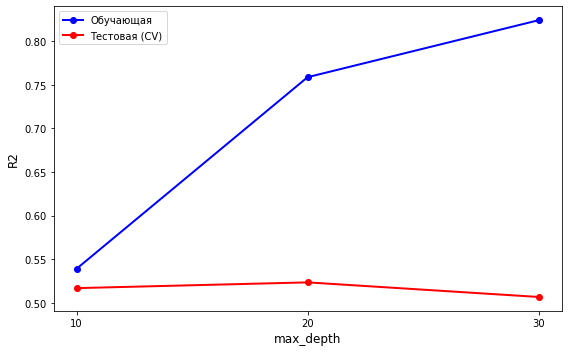

In [76]:
results = pd.DataFrame(grid_search.cv_results_)

depth_values = list(set(results['param_rf__max_depth']))
depth_values.sort()
train_scores = []
test_scores = []

for depth in depth_values:
    mask = results['param_rf__max_depth'] == depth
    train_scores.append(results[mask]['mean_train_score'].mean())
    test_scores.append(results[mask]['mean_test_score'].mean())

plt.figure(figsize=(8, 5))
plt.plot([str(d) for d in depth_values], train_scores, 'bo-', label='Обучающая', linewidth=2)
plt.plot([str(d) for d in depth_values], test_scores, 'ro-', label='Тестовая (CV)', linewidth=2)
plt.xlabel('max_depth', fontsize=12)
plt.ylabel('R2', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()


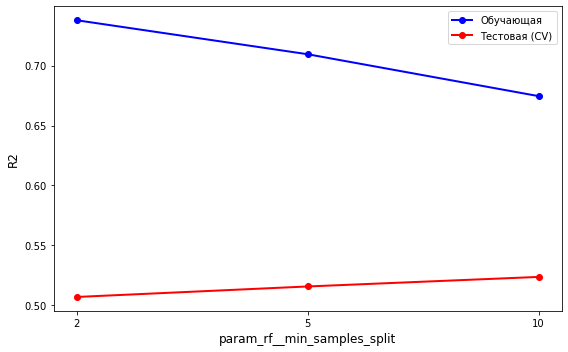

In [82]:
param_val = 'param_rf__min_samples_split'
params = list(set(results[param_val]))
params.sort()
train_scores = []
test_scores = []

for param in params:
    mask = results[param_val] == param
    train_scores.append(results[mask]['mean_train_score'].mean())
    test_scores.append(results[mask]['mean_test_score'].mean())

plt.figure(figsize=(8, 5))
plt.plot([str(d) for d in params], train_scores, 'bo-', label='Обучающая', linewidth=2)
plt.plot([str(d) for d in params], test_scores, 'ro-', label='Тестовая (CV)', linewidth=2)
plt.xlabel(param_val, fontsize=12)
plt.ylabel('R2', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

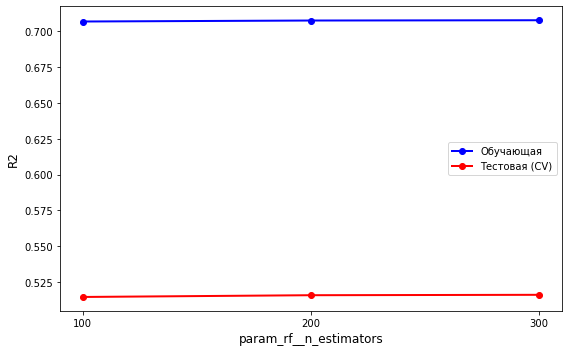

In [83]:
param_val = 'param_rf__n_estimators'
params = list(set(results[param_val]))
params.sort()
train_scores = []
test_scores = []

for param in params:
    mask = results[param_val] == param
    train_scores.append(results[mask]['mean_train_score'].mean())
    test_scores.append(results[mask]['mean_test_score'].mean())

plt.figure(figsize=(8, 5))
plt.plot([str(d) for d in params], train_scores, 'bo-', label='Обучающая', linewidth=2)
plt.plot([str(d) for d in params], test_scores, 'ro-', label='Тестовая (CV)', linewidth=2)
plt.xlabel(param_val, fontsize=12)
plt.ylabel('R2', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

In [72]:
results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_rf__max_depth,param_rf__min_samples_split,param_rf__n_estimators,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,mean_train_score,std_train_score
0,62.357386,1.088027,1.626980,0.006533,10,2,100,"{'rf__max_depth': 10, 'rf__min_samples_split':...",0.518355,0.519356,0.512077,0.516596,0.003222,19,0.539260,0.538159,0.542712,0.540043,0.001940
1,121.729152,1.317126,3.288209,0.013467,10,2,200,"{'rf__max_depth': 10, 'rf__min_samples_split':...",0.518606,0.519599,0.512179,0.516795,0.003289,12,0.539259,0.538393,0.542870,0.540174,0.001939
2,181.925690,0.473521,4.831068,0.008144,10,2,300,"{'rf__max_depth': 10, 'rf__min_samples_split':...",0.518562,0.519666,0.512154,0.516794,0.003312,13,0.539205,0.538394,0.542852,0.540150,0.001939
3,60.756697,0.052684,1.627651,0.004886,10,5,100,"{'rf__max_depth': 10, 'rf__min_samples_split':...",0.518459,0.519423,0.511919,0.516600,0.003334,18,0.538048,0.537374,0.541769,0.539064,0.001933
4,120.598076,0.793012,3.215765,0.009755,10,5,200,"{'rf__max_depth': 10, 'rf__min_samples_split':...",0.518687,0.519627,0.512062,0.516792,0.003367,14,0.538032,0.537562,0.541911,0.539168,0.001949
5,187.111764,1.364015,4.910513,0.035750,10,5,300,"{'rf__max_depth': 10, 'rf__min_samples_split':...",0.518621,0.519698,0.512056,0.516791,0.003377,15,0.537972,0.537551,0.541910,0.539144,0.001963
6,63.257120,1.930615,1.647624,0.058511,10,10,100,"{'rf__max_depth': 10, 'rf__min_samples_split':...",0.518529,0.519457,0.511958,0.516648,0.003338,17,0.536671,0.536233,0.540655,0.537853,0.001990
7,122.770843,1.840372,3.220147,0.007388,10,10,200,"{'rf__max_depth': 10, 'rf__min_samples_split':...",0.518681,0.519677,0.512113,0.516824,0.003356,10,0.536606,0.536385,0.540800,0.537930,0.002031
8,182.845533,0.913632,4.875768,0.033623,10,10,300,"{'rf__max_depth': 10, 'rf__min_samples_split':...",0.518584,0.519740,0.512078,0.516801,0.003373,11,0.536531,0.536371,0.540763,0.537888,0.002034
9,105.426121,1.037440,4.887468,0.115738,20,2,100,"{'rf__max_depth': 20, 'rf__min_samples_split':...",0.515557,0.516754,0.510702,0.514337,0.002617,21,0.793583,0.791479,0.795001,0.793354,0.001447


In [81]:
params

[100, 200, 300]

In [ ]:
param_grid = {
    'rf__n_estimators': [200, 300], 
    'rf__max_depth': [15, 20],  
    'rf__min_samples_split': [10, 20, 30, 40]
}

grid_search2 = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    cv=3,  
    scoring='r2',
    n_jobs=-1,
    verbose=4,
    return_train_score=True
)

grid_search2.fit(X_train, y_train)
results2 = pd.DataFrame(grid_search2.cv_results_)

for param, value in grid_search2.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nЛучший R2: {grid_search2.best_score_:.4f}")
print(f"R2 на тесте: {grid_search2.score(X_test, y_test):.4f}")

Fitting 3 folds for each of 16 candidates, totalling 48 fits
